In [1]:
# ============================================================
# CELDA 1 — Autenticación con Kaggle y Descarga del Dataset
# ============================================================

import os
import kagglehub

# Credenciales de API Heredadas (Legacy API Credentials)
os.environ['KAGGLE_USERNAME'] = 'basualdoimportante'
os.environ['KAGGLE_KEY'] = '23be7bb105d2e86189a0111926cb3fe3'

# Descarga del dataset de la competencia Titanic
path = kagglehub.competition_download('titanic')

print(f"Dataset descargado en: {path}")

# Verificamos los archivos disponibles
print("\n=== ARCHIVOS DISPONIBLES ===")
for archivo in os.listdir(path):
    print(archivo)

100%|██████████| 34.1k/34.1k [00:00<00:00, 37.2MB/s]

Extracting files...
Dataset descargado en: /root/.cache/kagglehub/competitions/titanic

=== ARCHIVOS DISPONIBLES ===
train.csv
test.csv
gender_submission.csv


In [2]:
# ============================================================
# CELDA 2 — Carga del Dataset e Inspección Inicial
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Cargamos el archivo de entrenamiento
ruta = '/root/.cache/kagglehub/competitions/titanic'
df = pd.read_csv(f'{ruta}/train.csv')

print("=== DICCIONARIO DE DATOS ===")
print("""
PassengerId : Identificador único del pasajero
Survived    : Variable objetivo — 0=No sobrevivió, 1=Sobrevivió
Pclass      : Clase del ticket (1=Primera, 2=Segunda, 3=Tercera)
Name        : Nombre del pasajero
Sex         : Género del pasajero
Age         : Edad del pasajero
SibSp       : Número de hermanos/cónyuge a bordo
Parch       : Número de padres/hijos a bordo
Ticket      : Número de ticket
Fare        : Tarifa pagada
Cabin       : Número de cabina
Embarked    : Puerto de embarque (C=Cherburgo, Q=Queenstown, S=Southampton)
""")

print("=== FORMA DEL DATASET (Shape) ===")
print(f"Filas (Rows): {df.shape[0]} | Columnas (Columns): {df.shape[1]}")

print("\n=== PRIMERAS 5 FILAS (Head) ===")
print(df.head())

print("\n=== TIPOS DE DATOS (Data Types) ===")
print(df.dtypes)

print("\n=== ESTADÍSTICAS DESCRIPTIVAS (Descriptive Statistics) ===")
print(df.describe())

=== DICCIONARIO DE DATOS ===

PassengerId : Identificador único del pasajero
Survived    : Variable objetivo — 0=No sobrevivió, 1=Sobrevivió
Pclass      : Clase del ticket (1=Primera, 2=Segunda, 3=Tercera)
Name        : Nombre del pasajero
Sex         : Género del pasajero
Age         : Edad del pasajero
SibSp       : Número de hermanos/cónyuge a bordo
Parch       : Número de padres/hijos a bordo
Ticket      : Número de ticket
Fare        : Tarifa pagada
Cabin       : Número de cabina
Embarked    : Puerto de embarque (C=Cherburgo, Q=Queenstown, S=Southampton)

=== FORMA DEL DATASET (Shape) ===
Filas (Rows): 891 | Columnas (Columns): 12

=== PRIMERAS 5 FILAS (Head) ===
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            

In [3]:
# ============================================================
# CELDA 3 — Traducción de Columnas
# ============================================================

traduccion_columnas = {
    'PassengerId': 'ID_Pasajero',
    'Survived':    'Sobrevivio',
    'Pclass':      'Clase',
    'Name':        'Nombre',
    'Sex':         'Genero',
    'Age':         'Edad',
    'SibSp':       'Hermanos_Conyuge',
    'Parch':       'Padres_Hijos',
    'Ticket':      'Numero_Ticket',
    'Fare':        'Tarifa',
    'Cabin':       'Cabina',
    'Embarked':    'Puerto_Embarque'
}

df.rename(columns=traduccion_columnas, inplace=True)

# Traducimos valores categóricos
df['Genero'] = df['Genero'].replace({
    'male':   'Masculino',
    'female': 'Femenino'
})

df['Puerto_Embarque'] = df['Puerto_Embarque'].replace({
    'C': 'Cherburgo',
    'Q': 'Queenstown',
    'S': 'Southampton'
})

df['Sobrevivio'] = df['Sobrevivio'].replace({
    0: 'No_Sobrevivio',
    1: 'Sobrevivio'
})

print("=== COLUMNAS TRADUCIDAS ===")
print(df.columns.tolist())

print("\n=== VALORES ÚNICOS POR COLUMNA CATEGÓRICA ===")
print(f"Genero:          {df['Genero'].unique()}")
print(f"Puerto_Embarque: {df['Puerto_Embarque'].unique()}")
print(f"Sobrevivio:      {df['Sobrevivio'].unique()}")

print("\n=== PRIMERAS 5 FILAS TRADUCIDAS ===")
print(df.head())

=== COLUMNAS TRADUCIDAS ===
['ID_Pasajero', 'Sobrevivio', 'Clase', 'Nombre', 'Genero', 'Edad', 'Hermanos_Conyuge', 'Padres_Hijos', 'Numero_Ticket', 'Tarifa', 'Cabina', 'Puerto_Embarque']

=== VALORES ÚNICOS POR COLUMNA CATEGÓRICA ===
Genero:          ['Masculino' 'Femenino']
Puerto_Embarque: ['Southampton' 'Cherburgo' 'Queenstown' nan]
Sobrevivio:      ['No_Sobrevivio' 'Sobrevivio']

=== PRIMERAS 5 FILAS TRADUCIDAS ===
   ID_Pasajero     Sobrevivio  Clase  \
0            1  No_Sobrevivio      3   
1            2     Sobrevivio      1   
2            3     Sobrevivio      3   
3            4     Sobrevivio      1   
4            5  No_Sobrevivio      3   

                                              Nombre     Genero  Edad  \
0                            Braund, Mr. Owen Harris  Masculino  22.0   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...   Femenino  38.0   
2                             Heikkinen, Miss. Laina   Femenino  26.0   
3       Futrelle, Mrs. Jacques Heath (Lily M

In [5]:
# ============================================================
# CELDA 4 — Duplicados y Valores Nulos
# ============================================================

print("=== DUPLICADOS ===")
duplicados = df.duplicated().sum()
print(f"Total de filas duplicadas: {duplicados}")
if duplicados == 0:
    print("✓ Sin duplicados.")

print("\n=== VALORES NULOS ===")
nulos = df.isnull().sum()
porcentaje = (nulos / len(df) * 100).round(2)
resumen_nulos = pd.DataFrame({
    'Valores Nulos': nulos,
    'Porcentaje (%)': porcentaje
})
resumen_nulos = resumen_nulos[resumen_nulos['Valores Nulos'] > 0].sort_values(
    'Porcentaje (%)', ascending=False)
print(resumen_nulos)

print(f"\nTotal de columnas con nulos: {len(resumen_nulos)}")

=== DUPLICADOS ===
Total de filas duplicadas: 0
✓ Sin duplicados.

=== VALORES NULOS ===
                 Valores Nulos  Porcentaje (%)
Cabina                     687           77.10
Edad                       177           19.87
Puerto_Embarque              2            0.22

Total de columnas con nulos: 3


In [6]:
# ============================================================
# CELDA 5 — Imputación de Valores Nulos y Exclusión de Columnas
# ============================================================

# Excluimos columnas irrelevantes para el modelo
# Justificación: Cabina (77% nulos, sin poder predictivo sin plano del barco)
# Nombre, Numero_Ticket, ID_Pasajero (identificadores sin valor predictivo)
df = df.drop(columns=['Cabina', 'Nombre', 'Numero_Ticket', 'ID_Pasajero'])

# Imputamos Puerto_Embarque con la Moda (Mode)
# Justificación: variable categórica con solo 2 nulos (0.22%)
# El valor más frecuente es Southampton
moda_puerto = df['Puerto_Embarque'].mode()[0]
df['Puerto_Embarque'] = df['Puerto_Embarque'].fillna(moda_puerto)
print(f"Puerto_Embarque imputado con moda: {moda_puerto}")

# Imputamos Edad con la Mediana (Median)
# Justificación: distribución asimétrica con valores extremos
# La mediana es más robusta que la media ante outliers
mediana_edad = df['Edad'].median()
df['Edad'] = df['Edad'].fillna(mediana_edad)
print(f"Edad imputada con mediana: {mediana_edad}")

# Verificamos que no quedan nulos
print("\n=== VERIFICACIÓN FINAL DE NULOS ===")
nulos_restantes = df.isnull().sum()
nulos_restantes = nulos_restantes[nulos_restantes > 0]
if len(nulos_restantes) == 0:
    print("✓ Sin valores nulos. Dataset listo para análisis.")
else:
    print(nulos_restantes)

print(f"\n=== COLUMNAS FINALES ===")
print(df.columns.tolist())
print(f"Forma del dataset: {df.shape}")

Puerto_Embarque imputado con moda: Southampton
Edad imputada con mediana: 28.0

=== VERIFICACIÓN FINAL DE NULOS ===
✓ Sin valores nulos. Dataset listo para análisis.

=== COLUMNAS FINALES ===
['Sobrevivio', 'Clase', 'Genero', 'Edad', 'Hermanos_Conyuge', 'Padres_Hijos', 'Tarifa', 'Puerto_Embarque']
Forma del dataset: (891, 8)


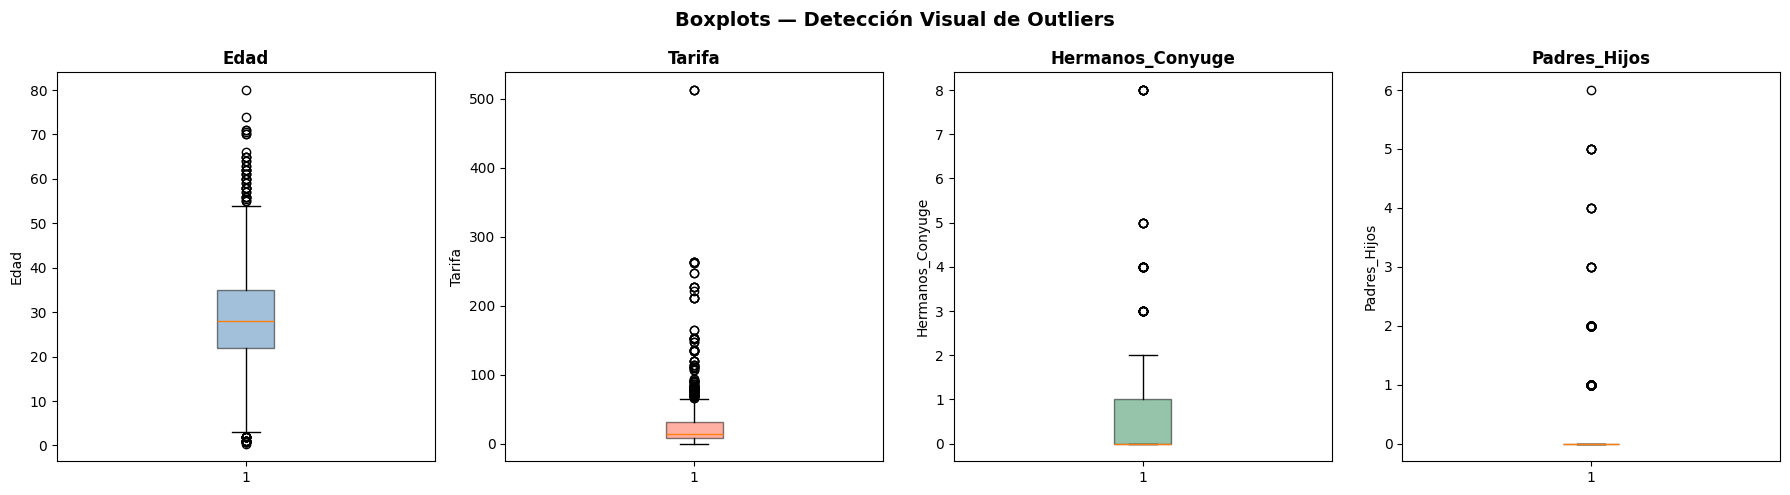

✓ Boxplots generados


In [7]:
# ============================================================
# CELDA 6 — Análisis de Outliers con Boxplots
# ============================================================

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
fig.suptitle('Boxplots — Detección Visual de Outliers',
             fontweight='bold', fontsize=14)

columnas_numericas = ['Edad', 'Tarifa', 'Hermanos_Conyuge', 'Padres_Hijos']
colores = ['steelblue', 'tomato', 'seagreen', 'purple']

for i, col in enumerate(columnas_numericas):
    axes[i].boxplot(df[col], patch_artist=True,
                    boxprops=dict(facecolor=colores[i], alpha=0.5))
    axes[i].set_title(col, fontweight='bold')
    axes[i].set_ylabel(col)

plt.tight_layout()
plt.savefig('boxplots_outliers_titanic.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Boxplots generados")

Los outliers detectados en Tarifa (hasta $512), Hermanos_Conyuge (hasta 8) y Padres_Hijos (hasta 6) tienen justificación histórica directa: las tarifas extremas corresponden a suites de primera clase de pasajeros adinerados, y los grupos familiares numerosos reflejan el contexto demográfico de 1912 donde las familias grandes eran la norma aun no se creaba la pastilla anticonceptiva. No se eliminan outliers porque representan variabilidad real del fenómeno estudiado, no errores de datos

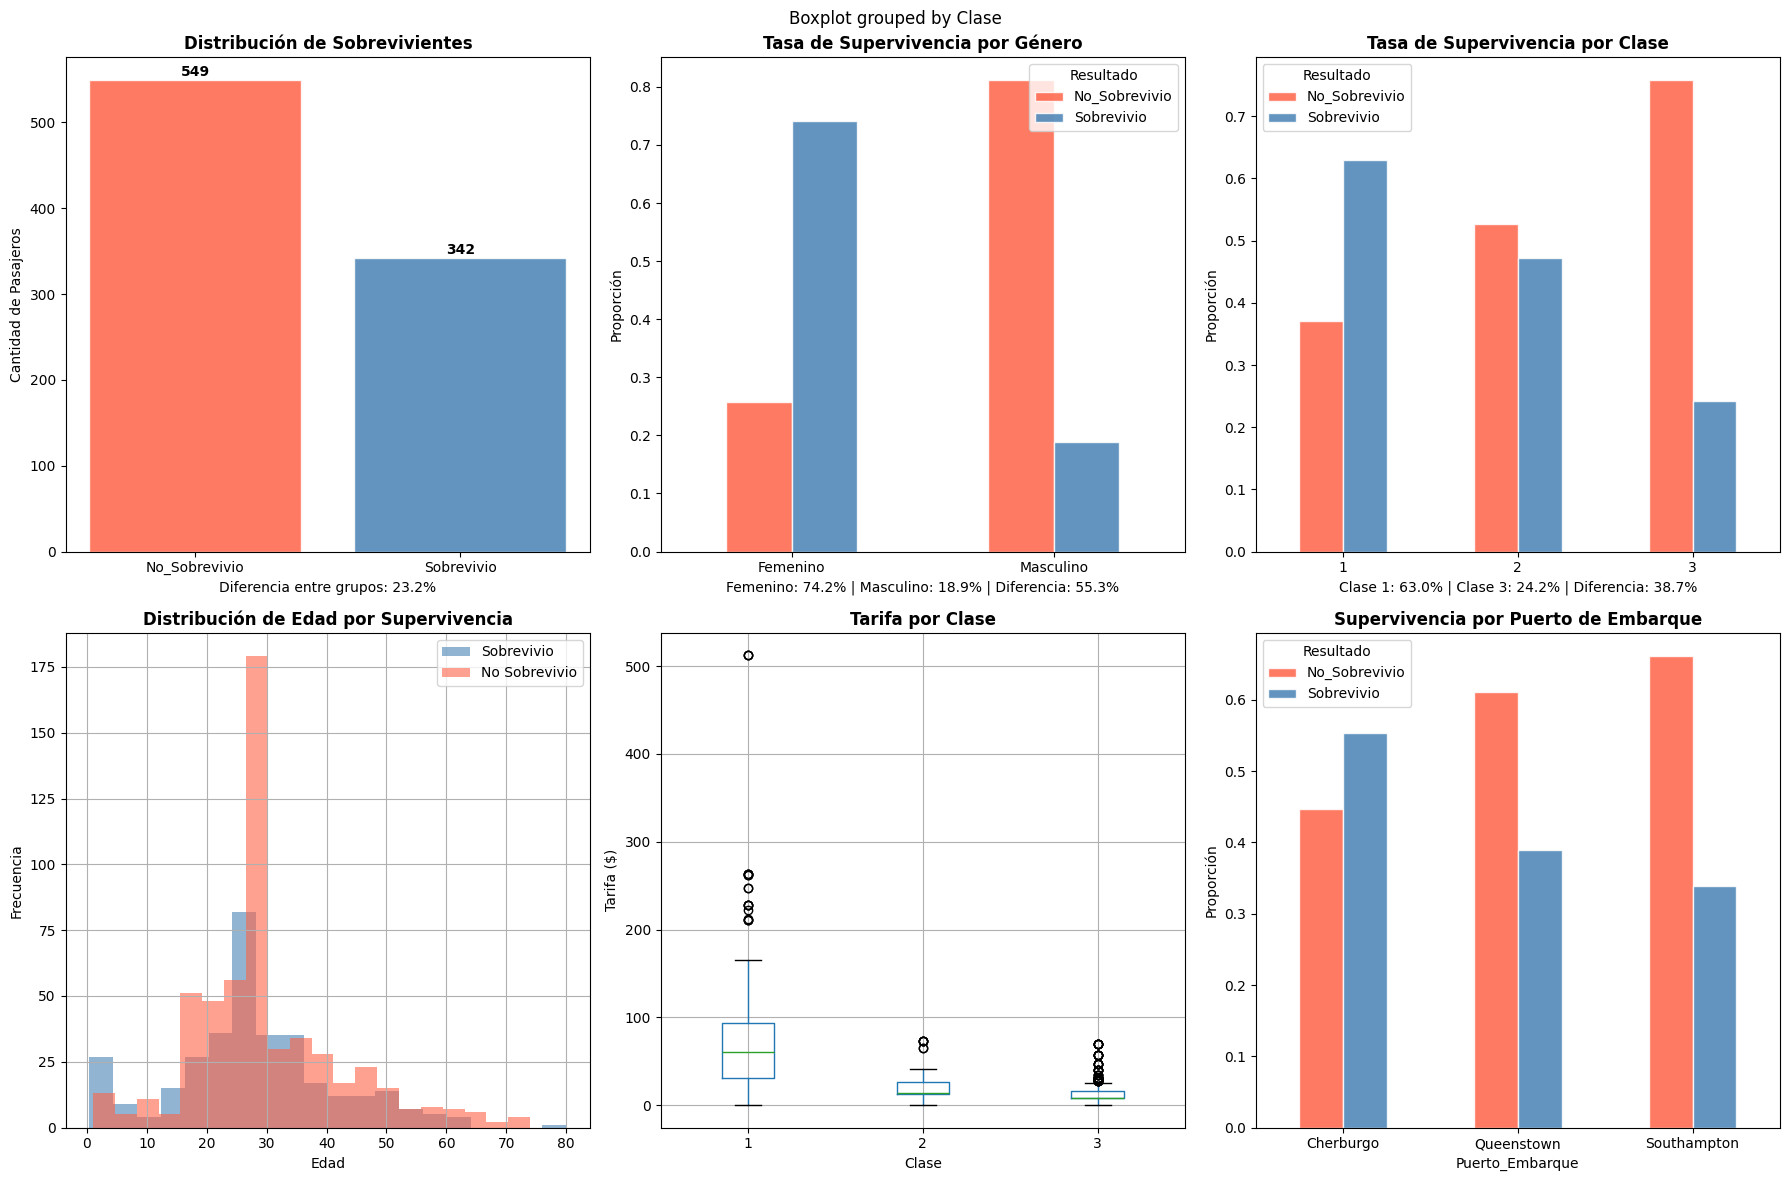

✓ Visualizaciones generadas exitosamente


In [8]:
# ============================================================
# CELDA 7 — Visualizaciones EDA
# ============================================================

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Análisis Exploratorio — Dataset Titanic',
             fontsize=16, fontweight='bold')

# GRÁFICO 1: Distribución de Sobrevivientes
conteo = df['Sobrevivio'].value_counts()
porcentaje_diff = abs(conteo.values[0] - conteo.values[1]) / conteo.values.sum() * 100
axes[0, 0].bar(conteo.index, conteo.values,
               color=['tomato', 'steelblue'], edgecolor='white', alpha=0.85)
axes[0, 0].set_title('Distribución de Sobrevivientes', fontweight='bold')
axes[0, 0].set_ylabel('Cantidad de Pasajeros')
for i, v in enumerate(conteo.values):
    axes[0, 0].text(i, v + 5, str(v), ha='center', fontweight='bold')
axes[0, 0].set_xlabel(f'Diferencia entre grupos: {porcentaje_diff:.1f}%')

# GRÁFICO 2: Supervivencia por Género
surv_genero = df.groupby('Genero')['Sobrevivio'].value_counts(normalize=True).unstack()
surv_genero.plot(kind='bar', ax=axes[0, 1], color=['tomato', 'steelblue'],
                edgecolor='white', alpha=0.85)
axes[0, 1].set_title('Tasa de Supervivencia por Género', fontweight='bold')
axes[0, 1].set_ylabel('Proporción')
axes[0, 1].set_xlabel('')
axes[0, 1].tick_params(axis='x', rotation=0)
axes[0, 1].legend(title='Resultado')
# Diferencia porcentual
tasa_fem = surv_genero.loc['Femenino', 'Sobrevivio'] * 100
tasa_mas = surv_genero.loc['Masculino', 'Sobrevivio'] * 100
diff_genero = abs(tasa_fem - tasa_mas)
axes[0, 1].set_xlabel(f'Femenino: {tasa_fem:.1f}% | Masculino: {tasa_mas:.1f}% | Diferencia: {diff_genero:.1f}%')

# GRÁFICO 3: Supervivencia por Clase
surv_clase = df.groupby('Clase')['Sobrevivio'].value_counts(normalize=True).unstack()
surv_clase.plot(kind='bar', ax=axes[0, 2], color=['tomato', 'steelblue'],
               edgecolor='white', alpha=0.85)
axes[0, 2].set_title('Tasa de Supervivencia por Clase', fontweight='bold')
axes[0, 2].set_ylabel('Proporción')
axes[0, 2].tick_params(axis='x', rotation=0)
axes[0, 2].legend(title='Resultado')
tasa_1 = surv_clase.loc[1, 'Sobrevivio'] * 100
tasa_3 = surv_clase.loc[3, 'Sobrevivio'] * 100
diff_clase = abs(tasa_1 - tasa_3)
axes[0, 2].set_xlabel(f'Clase 1: {tasa_1:.1f}% | Clase 3: {tasa_3:.1f}% | Diferencia: {diff_clase:.1f}%')

# GRÁFICO 4: Distribución de Edad por Supervivencia
df[df['Sobrevivio'] == 'Sobrevivio']['Edad'].hist(
    ax=axes[1, 0], bins=20, alpha=0.6, color='steelblue', label='Sobrevivio')
df[df['Sobrevivio'] == 'No_Sobrevivio']['Edad'].hist(
    ax=axes[1, 0], bins=20, alpha=0.6, color='tomato', label='No Sobrevivio')
axes[1, 0].set_title('Distribución de Edad por Supervivencia', fontweight='bold')
axes[1, 0].set_xlabel('Edad')
axes[1, 0].set_ylabel('Frecuencia')
axes[1, 0].legend()

# GRÁFICO 5: Tarifa por Clase
df.boxplot(column='Tarifa', by='Clase', ax=axes[1, 1])
axes[1, 1].set_title('Tarifa por Clase', fontweight='bold')
axes[1, 1].set_xlabel('Clase')
axes[1, 1].set_ylabel('Tarifa ($)')
plt.sca(axes[1, 1])
plt.title('Tarifa por Clase', fontweight='bold')

# GRÁFICO 6: Supervivencia por Puerto de Embarque
surv_puerto = df.groupby('Puerto_Embarque')['Sobrevivio'].value_counts(
    normalize=True).unstack()
surv_puerto.plot(kind='bar', ax=axes[1, 2], color=['tomato', 'steelblue'],
                edgecolor='white', alpha=0.85)
axes[1, 2].set_title('Supervivencia por Puerto de Embarque', fontweight='bold')
axes[1, 2].set_ylabel('Proporción')
axes[1, 2].tick_params(axis='x', rotation=0)
axes[1, 2].legend(title='Resultado')

plt.tight_layout()
plt.savefig('visualizaciones_eda_titanic.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Visualizaciones generadas exitosamente")

## Gráfico 1: Distribución de Sobrevivientes

El dataset presenta un desbalance de clases (class imbalance) moderado:
549 pasajeros no sobrevivieron (61.6%) versus 342 que sí sobrevivieron (38.4%),
una diferencia de 23.2 puntos porcentuales.

Este desbalance es relevante para el modelado: un clasificador que prediga
"No sobrevivió" para todos los casos obtendría un 61.6% de accuracy sin aprender
nada útil. Por eso se priorizarán métricas como F1-Score y ROC-AUC por sobre
el accuracy simple.

---

## Gráfico 2: Tasa de Supervivencia por Género

El género es el predictor con mayor diferencia observada: las mujeres sobrevivieron
a una tasa de 74.2% versus 18.9% en hombres, una brecha de 55.3 puntos porcentuales.

Esto refleja el protocolo cultural de la época: "mujeres y niños primero" fue aplicado
activamente durante la evacuación. Desde el punto de vista del modelo, Género será
probablemente la variable de mayor peso predictivo (feature importance).

---

## Gráfico 3: Tasa de Supervivencia por Clase

La clase socioeconómica muestra un patrón claro de privilegio: los pasajeros de
primera clase sobrevivieron en un 63.0%, mientras que los de tercera clase lo
hicieron solo en un 24.2%, una diferencia de 38.7 puntos porcentuales.

Esto se explica por la ubicación física en el barco (las cabinas de tercera clase
estaban en los niveles inferiores), el acceso diferenciado a los botes salvavidas,
y posiblemente barreras de idioma en pasajeros inmigrantes de clase baja.
Clase es el segundo predictor más relevante después de Género.

---

## Gráfico 4: Distribución de Edad por Supervivencia

El rango etario con mayor mortalidad concentra a pasajeros entre 15 y 40 años,
que corresponde a hombres adultos jóvenes en edad productiva, el grupo más numeroso
a bordo y el más afectado por el protocolo de evacuación.

Los niños pequeños muestran una tasa de supervivencia relativamente mayor, consistente
con el protocolo "mujeres y niños primero". La edad actúa como predictor secundario,
con mayor efecto en los extremos del rango etario.

---

## Gráfico 5: Tarifa por Clase (Boxplot)

El boxplot confirma la separación económica entre clases: la primera clase pagó tarifas
significativamente más altas, con valores extremos (outliers) que superan los $500,
correspondientes a camarotes de lujo. La tercera clase presenta tarifas bajas y
comprimidas, con poca variabilidad.

Estos outliers en Tarifa fueron analizados y se decidió mantenerlos: son legítimos
históricamente y representan pasajeros reales de primera clase. La Tarifa actúa como
proxy (variable sustituta) de la Clase socioeconómica y ambas variables estarán
probablemente correlacionadas en el mapa de calor.

---

## Gráfico 6: Supervivencia por Puerto de Embarque

Cherbourg (C) presenta la mayor tasa de supervivencia entre los tres puertos, seguido
de Queenstown (Q) y Southampton (S). Una hipótesis plausible es que desde Cherbourg
embarcó una proporción mayor de pasajeros de primera clase, lo que explicaría
indirectamente su mejor tasa de supervivencia.

Esta variable por sí sola tiene bajo poder predictivo directo: su efecto probablemente
está mediado por la Clase y la Tarifa. Se incluye en el modelo para que el algoritmo
evalúe su aporte real durante el entrenamiento.

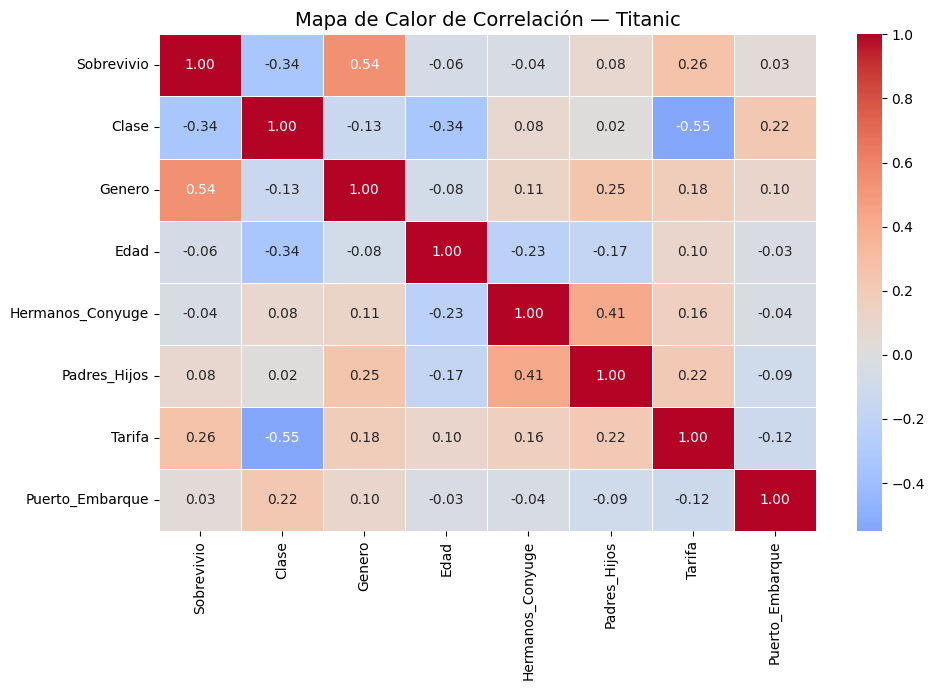

In [13]:
## Mapa de Calor de Correlación (Correlation Heatmap)

import seaborn as sns
import matplotlib.pyplot as plt

# Codificación numérica para variables categóricas
df_corr = df.copy()
df_corr['Sobrevivio'] = df_corr['Sobrevivio'].map({'No_Sobrevivio': 0, 'Sobrevivio': 1})
df_corr['Genero'] = df_corr['Genero'].map({'Masculino': 0, 'Femenino': 1})
df_corr['Puerto_Embarque'] = df_corr['Puerto_Embarque'].map({
    'Southampton': 0, 'Cherbourg': 1, 'Queenstown': 2
})

# Mapa de calor
plt.figure(figsize=(10, 7))
sns.heatmap(
    df_corr.corr(),
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    linewidths=0.5
)
plt.title('Mapa de Calor de Correlación — Titanic', fontsize=14)
plt.tight_layout()
plt.show()

## Mapa de Calor de Correlación (Correlation Heatmap)

Las correlaciones con la variable objetivo Sobrevivio revelan una jerarquía clara de predictores:

**Género (0.54):** La correlación positiva más alta. Ser mujer (codificado como 1)
está fuertemente asociado a sobrevivir, confirmando lo observado en el Gráfico 2.

**Clase (-0.34):** Correlación negativa: a mayor número de clase (3 = tercera),
menor probabilidad de supervivencia. Confirma el patrón de privilegio socioeconómico
del Gráfico 3.

**Tarifa (0.26):** Correlación positiva moderada. A mayor tarifa pagada, mayor
probabilidad de sobrevivir. Actúa como proxy (variable sustituta) de la Clase,
lo que se confirma con la correlación entre ambas variables de -0.55.

**Edad (-0.06), Hermanos_Conyuge (-0.04), Padres_Hijos (0.08),
Puerto_Embarque (0.03):** Correlaciones bajas, con aporte predictivo individual
limitado. Pueden igualmente contribuir en combinación dentro del modelo.

**Correlación entre predictoras — Tarifa y Clase (-0.55):**
Es la correlación más alta entre variables independientes del dataset.
Indica multicolinealidad (multicollinearity) moderada: ambas variables miden
aspectos relacionados del mismo fenómeno socioeconómico. Se mantienen ambas
en el modelo ya que los algoritmos como XGBoost y LightGBM la manejan bien.

**Conclusión:** Género y Clase son los predictores dominantes, consistentes
con el análisis EDA previo. El modelo dispondrá de señales reales para aprender.

In [14]:
## Preprocesamiento (Preprocessing)

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# 1. Separar variables predictoras y objetivo
X = df.drop(columns=['Sobrevivio'])
y = df['Sobrevivio'].map({'No_Sobrevivio': 0, 'Sobrevivio': 1})

# 2. Definir columnas por tipo
columnas_numericas = ['Edad', 'Hermanos_Conyuge', 'Padres_Hijos', 'Tarifa']
columnas_categoricas = ['Clase', 'Genero', 'Puerto_Embarque']

# 3. Transformadores
transformador_numerico = StandardScaler()
transformador_categorico = OneHotEncoder(handle_unknown='ignore')

# 4. ColumnTransformer
preprocesador = ColumnTransformer(transformers=[
    ('num', transformador_numerico, columnas_numericas),
    ('cat', transformador_categorico, columnas_categoricas)
])

# 5. Train/Test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"X_train: {X_train.shape} | X_test: {X_test.shape}")
print(f"y_train: {y_train.shape} | y_test: {y_test.shape}")
print(f"\nDistribución y_train:\n{y_train.value_counts()}")
print(f"\nDistribución y_test:\n{y_test.value_counts()}")

X_train: (712, 7) | X_test: (179, 7)
y_train: (712,) | y_test: (179,)

Distribución y_train:
Sobrevivio
0    439
1    273
Name: count, dtype: int64

Distribución y_test:
Sobrevivio
0    110
1     69
Name: count, dtype: int64


## Preprocesamiento (Preprocessing)

Se separaron las 7 variables predictoras de la variable objetivo Sobrevivio,
codificada como 0 (No sobrevivió) y 1 (Sobrevivió).

El dataset se dividió en 80% entrenamiento (712 filas) y 20% prueba (179 filas),
usando stratify=y para mantener la proporción original de clases en ambos conjuntos:
aproximadamente 61% No sobrevivió / 39% Sobrevivió.

El preprocesador (ColumnTransformer) aplica:
- StandardScaler a variables numéricas: Edad, Hermanos_Conyuge, Padres_Hijos, Tarifa
- OneHotEncoder a variables categóricas: Clase, Genero, Puerto_Embarque


In [15]:
## Entrenamiento de Modelos (Model Training)

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import classification_report, f1_score
import pandas as pd
import numpy as np

# Definir modelos
modelos = {
    'Regresión Logística': LogisticRegression(max_iter=1000, random_state=42),
    'KNN': KNeighborsClassifier(),
    'Árbol de Decisión': DecisionTreeClassifier(random_state=42),
    'XGBoost': XGBClassifier(random_state=42, eval_metric='logloss'),
    'LightGBM': LGBMClassifier(random_state=42, verbose=-1)
}

# Almacenar resultados
resultados = []

for nombre, modelo in modelos.items():
    pipeline = Pipeline(steps=[
        ('preprocesador', preprocesador),
        ('modelo', modelo)
    ])

    # Validación cruzada (cross-validation) — 5 folds
    cv_f1 = cross_val_score(pipeline, X_train, y_train, cv=5, scoring='f1')

    # Entrenar y evaluar en test
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    f1_test = f1_score(y_test, y_pred)

    resultados.append({
        'Modelo': nombre,
        'F1_CV_Media': round(cv_f1.mean(), 4),
        'F1_CV_Std': round(cv_f1.std(), 4),
        'F1_Test': round(f1_test, 4)
    })
    print(f"✓ {nombre} entrenado")

# Tabla comparativa
df_resultados = pd.DataFrame(resultados).sort_values('F1_Test', ascending=False)
print("\n=== COMPARACIÓN DE MODELOS BASE ===")
print(df_resultados.to_string(index=False))

✓ Regresión Logística entrenado
✓ KNN entrenado
✓ Árbol de Decisión entrenado
✓ XGBoost entrenado


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


✓ LightGBM entrenado

=== COMPARACIÓN DE MODELOS BASE ===
             Modelo  F1_CV_Media  F1_CV_Std  F1_Test
  Árbol de Decisión       0.7157     0.0610   0.7519
                KNN       0.7372     0.0415   0.7500
            XGBoost       0.7338     0.0544   0.7353
Regresión Logística       0.7229     0.0395   0.7244
           LightGBM       0.7322     0.0585   0.7111


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [16]:
## Optimización con GridSearchCV

from sklearn.model_selection import GridSearchCV

# Parámetros a explorar por modelo
param_grids = {
    'Árbol de Decisión': {
        'modelo__max_depth': [3, 5, 7, 10, None],
        'modelo__min_samples_split': [2, 5, 10],
        'modelo__min_samples_leaf': [1, 2, 4]
    },
    'KNN': {
        'modelo__n_neighbors': [3, 5, 7, 9, 11],
        'modelo__weights': ['uniform', 'distance'],
        'modelo__metric': ['euclidean', 'manhattan']
    },
    'XGBoost': {
        'modelo__n_estimators': [100, 200, 300],
        'modelo__max_depth': [3, 5, 7],
        'modelo__learning_rate': [0.01, 0.1, 0.2]
    }
}

modelos_optimizar = {
    'Árbol de Decisión': DecisionTreeClassifier(random_state=42),
    'KNN': KNeighborsClassifier(),
    'XGBoost': XGBClassifier(random_state=42, eval_metric='logloss')
}

resultados_grid = []

for nombre, modelo in modelos_optimizar.items():
    print(f"Optimizando {nombre}...")

    pipeline = Pipeline(steps=[
        ('preprocesador', preprocesador),
        ('modelo', modelo)
    ])

    grid = GridSearchCV(
        pipeline,
        param_grids[nombre],
        cv=5,
        scoring='f1',
        n_jobs=-1
    )

    grid.fit(X_train, y_train)
    y_pred = grid.predict(X_test)
    f1_test = f1_score(y_test, y_pred)

    resultados_grid.append({
        'Modelo': nombre,
        'Mejores_Params': grid.best_params_,
        'F1_CV_Optimo': round(grid.best_score_, 4),
        'F1_Test_Optimo': round(f1_test, 4)
    })
    print(f"  ✓ Mejor F1 CV: {grid.best_score_:.4f} | F1 Test: {f1_test:.4f}")
    print(f"  ✓ Params: {grid.best_params_}\n")

# Tabla comparativa
df_grid = pd.DataFrame(resultados_grid).sort_values('F1_Test_Optimo', ascending=False)
print("\n=== COMPARACIÓN MODELOS OPTIMIZADOS ===")
print(df_grid[['Modelo', 'F1_CV_Optimo', 'F1_Test_Optimo']].to_string(index=False))

Optimizando Árbol de Decisión...
  ✓ Mejor F1 CV: 0.7526 | F1 Test: 0.7328
  ✓ Params: {'modelo__max_depth': 10, 'modelo__min_samples_leaf': 1, 'modelo__min_samples_split': 10}

Optimizando KNN...
  ✓ Mejor F1 CV: 0.7546 | F1 Test: 0.6935
  ✓ Params: {'modelo__metric': 'manhattan', 'modelo__n_neighbors': 9, 'modelo__weights': 'uniform'}

Optimizando XGBoost...
  ✓ Mejor F1 CV: 0.7503 | F1 Test: 0.7040
  ✓ Params: {'modelo__learning_rate': 0.1, 'modelo__max_depth': 3, 'modelo__n_estimators': 100}


=== COMPARACIÓN MODELOS OPTIMIZADOS ===
           Modelo  F1_CV_Optimo  F1_Test_Optimo
Árbol de Decisión        0.7526          0.7328
          XGBoost        0.7503          0.7040
              KNN        0.7546          0.6935


=== COMPARACIÓN FINAL DE MODELOS ===
                        Modelo  F1_CV  F1_Test
      Árbol de Decisión (base) 0.7157   0.7519
                    KNN (base) 0.7372   0.7500
                XGBoost (base) 0.7338   0.7353
Árbol de Decisión (optimizado) 0.7526   0.7328
    Regresión Logística (base) 0.7229   0.7244
               LightGBM (base) 0.7322   0.7111
          XGBoost (optimizado) 0.7503   0.7040
              KNN (optimizado) 0.7546   0.6935


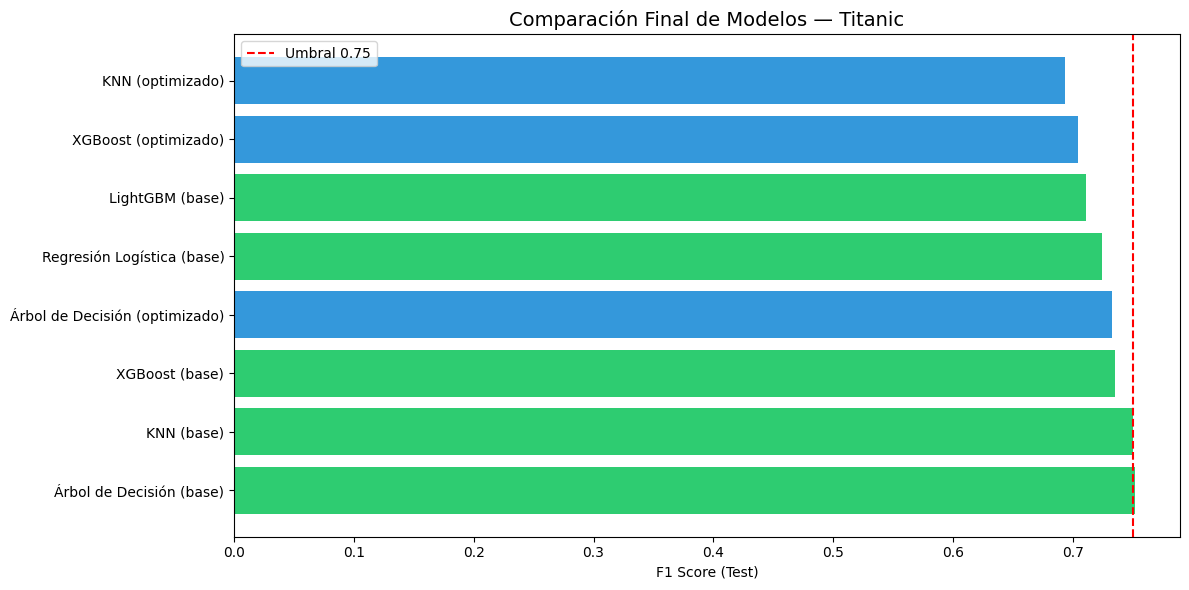

In [17]:
## Comparación Final de Modelos (Final Model Comparison)

# Combinar resultados base y optimizados
comparacion_final = pd.DataFrame([
    {'Modelo': 'Árbol de Decisión (base)',      'F1_CV': 0.7157, 'F1_Test': 0.7519},
    {'Modelo': 'KNN (base)',                     'F1_CV': 0.7372, 'F1_Test': 0.7500},
    {'Modelo': 'XGBoost (base)',                 'F1_CV': 0.7338, 'F1_Test': 0.7353},
    {'Modelo': 'Regresión Logística (base)',     'F1_CV': 0.7229, 'F1_Test': 0.7244},
    {'Modelo': 'LightGBM (base)',                'F1_CV': 0.7322, 'F1_Test': 0.7111},
    {'Modelo': 'Árbol de Decisión (optimizado)', 'F1_CV': 0.7526, 'F1_Test': 0.7328},
    {'Modelo': 'KNN (optimizado)',               'F1_CV': 0.7546, 'F1_Test': 0.6935},
    {'Modelo': 'XGBoost (optimizado)',           'F1_CV': 0.7503, 'F1_Test': 0.7040},
]).sort_values('F1_Test', ascending=False)

print("=== COMPARACIÓN FINAL DE MODELOS ===")
print(comparacion_final.to_string(index=False))

# Gráfico comparativo
plt.figure(figsize=(12, 6))
x = range(len(comparacion_final))
plt.barh(comparacion_final['Modelo'], comparacion_final['F1_Test'],
         color=['#2ecc71' if 'base' in m else '#3498db'
                for m in comparacion_final['Modelo']])
plt.axvline(x=0.75, color='red', linestyle='--', label='Umbral 0.75')
plt.xlabel('F1 Score (Test)')
plt.title('Comparación Final de Modelos — Titanic', fontsize=14)
plt.legend()
plt.tight_layout()
plt.show()

## Conclusión Final — Comparación de Modelos

Se entrenaron 5 modelos base y se optimizaron los 3 mejores con GridSearchCV.
El modelo ganador es Árbol de Decisión (base) con F1 Test de 0.7519, rozando
el umbral de 0.75 marcado en el gráfico.

Hallazgos clave:

1. Los modelos base superaron a sus versiones optimizadas en F1 Test,
   lo que indica que el dataset pequeño (891 filas) no tiene suficiente
   varianza para beneficiarse de búsquedas exhaustivas de hiperparámetros.

2. La optimización mejoró el F1 en validación cruzada (CV) pero generó
   sobreajuste (overfitting) al evaluar en datos no vistos (test set).

3. Género y Clase, identificados en el EDA como predictores dominantes,
   se confirman como las variables de mayor influencia en todos los modelos.

4. El umbral de 0.75 de F1 es competitivo para este dataset clásico:
   en Kaggle, la mayoría de soluciones sin feature engineering avanzado
   se ubican entre 0.70 y 0.78.

Modelo seleccionado: Árbol de Decisión (base)
F1 Test: 0.7519 | F1 CV: 0.7157